(03-17-termijnstructuur-real-options)=

# Brennan-Schwartz, Vasicek, CIR en Longstaff-Schwartz

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1977–2001, met het zwaartepunt tussen 1977 en 1992.

**Wat we al weten.** [Black, Scholes en Merton](#02-09-black-scholes) prijsden een
optie door haar met het aandeel te repliceren, en
[de fundamentele stelling](#03-11-apt-no-arbitrage) liet zien dat zo'n prijs een
verwachting onder een martingaalmaat is. Beide leunen op een verhandelde
onderliggende waarde en een constante rente.
[Basu, Banz en Rosenberg](#03-16-vroege-anomalieen) vonden intussen barsten in de
cross-sectie van aandelen, waar kenmerken de prijzen leken te drijven; hier gaat het
om prijzen die door toestandsvariabelen worden gedreven.

**Welke vraag staat open.** Hoe prijs je een claim waarvan de drijvende variabele,
zoals de korte rente, een koperprijs of de keuze om een mijn te sluiten, zelf niet te
koop is?
```

## Overzicht

In het verhaal van Pedro Santa-Clara is dit de UCLA-lijn: Michael Brennan en Eduardo
Schwartz waren zijn mentoren {cite}`SantaClara2026`, en in de dankbetuiging van
{cite:t}`LongstaffSchwartz2001` staat hij tussen de commentatoren. Hun werk levert
gereedschap om prijzen te *maken* voor alles wat van een onzekere toestand afhangt.

{cite:t}`Vasicek1977` liet met een arbitrageargument zien dat alle obligaties dezelfde
vergoeding per eenheid renterisico bieden, en gaf een gesloten formule voor de hele
rentecurve. {cite:t}`BrennanSchwartz1979` voegden de lange rente als tweede factor toe,
{cite:t}`CoxIngersollRoss1985` leidden een positieve rente af uit een algemeen evenwicht,
{cite:t}`LongstaffSchwartz1992` bouwden een tweefactormodel met gesloten formules, en
{cite:t}`DuffieKan1996` lieten zien wat deze modellen delen: ze zijn *affien* (de
logaritme van de obligatieprijs is lineair in de factoren). Op een grondstof toegepast
werd dezelfde wiskunde de theorie van *real options* (opties in een
investeringsproject: wachten, sluiten, opgeven)
{cite}`BrennanSchwartz1985,McDonaldSiegel1986,Schwartz1997`. De lijn eindigt bij de
*least-squares Monte Carlo* waarmee de praktijk sindsdien Amerikaanse opties op veel
factoren prijst {cite}`LongstaffSchwartz2001`.

De epistemische status (motief 3) is die van Black-Scholes: een relatieve
waarderingsregel die zegt wat een obligatie waard is *gegeven* de rentedynamiek en één
marktprijs van risico, toetsbaar op tweede momenten en op de vorm van de curve. Na een
rentenboom en een mijn van twee perioden leiden we de termijnstructuur-PDE en de affiene
formules af, simuleren Vasicek, CIR en LSM, en schatten Vasicek en CIR op de
driemaandsrente. Een eenfactormodel past de korte en de lange kant van de curve niet
tegelijk, en een principale-componentenanalyse op de curve van
{cite:t}`GurkaynakSackWright2007` vindt, zoals bij {cite:t}`LittermanScheinkman1991`,
drie factoren.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import optimize, stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

De korte rente is een prijs, geen activum: een tienjaarsobligatie kun je er niet mee
repliceren. Vasiceks uitweg was dat alle obligaties door dezelfde renteschok bewegen,
zodat je de ene met de andere kunt afdekken. Zo'n portefeuille is zonder risico en moet
de korte rente opleveren, dus bieden beide obligaties hetzelfde extra rendement per
eenheid risico. Die ene verhouding, de *marktprijs van risico*, is alles wat de markt
over voorkeuren hoeft te vertellen.

Het tweede idee is dat de rente terugtrekt naar een gemiddelde, zodat de vorm van de
curve afhangt van waar de rente nu staat. Bij Vasicek is de rente normaal verdeeld en
kan ze negatief worden; bij Cox, Ingersoll en Ross krimpen de schokken bij een lage
rente, zodat ze positief blijft. Met één bron van onzekerheid bewegen in beide modellen
alle rentes perfect samen, en in de data doen ze dat niet.

Hetzelfde argument prijst een mijn: een kopermijn is een reeks opties op koper, delven
als de prijs de kosten dekt en sluiten als dat niet zo is. Een netto contante waarde met
de verwachte koperprijs rekent alsof je in verliesjaren moet doorwerken, en onderschat
de mijn met de waarde van die flexibiliteit.

Het laatste idee is numeriek. Een Amerikaanse optie oefen je uit zodra uitoefenen meer
oplevert dan doorgaan, en "doorgaan" is een voorwaardelijke verwachting. Longstaff en
Schwartz schatten die met kleinste kwadraten uit gesimuleerde paden; omdat een geschatte
regel nooit beter is dan de optimale, is het resultaat een controleerbare ondergrens.

## Toy-voorbeeld: een rentenboom en een mijn van twee perioden

### Een obligatie en een Amerikaanse put in een Ho-Lee-boom

Neem een boom in de geest van {cite:t}`HoLee1986`: de korte rente per periode begint op
5% en gaat elke periode met risiconeutrale kans $\tfrac12$ drie procentpunt omhoog of
omlaag.

| $t=0$ | $t=1$ | $t=2$ |
|---|---|---|
| 5% | 8% / 2% | 11% / 5% / $-1$% |

Een euro op $t+1$ is op $t$ waard $1/(1+r_t)$ keer de verwachte waarde in de volgende
knopen. Voor een nulcouponobligatie die op $t=3$ één euro uitkeert:

$$
\begin{aligned}
t=2:&\quad \tfrac{1}{1{,}11}=0{,}900901,\quad \tfrac{1}{1{,}05}=0{,}952381,\quad \tfrac{1}{0{,}99}=1{,}010101,\\
t=1:&\quad \tfrac{\tfrac12(0{,}900901+0{,}952381)}{1{,}08}=0{,}858001,\qquad
          \tfrac{\tfrac12(0{,}952381+1{,}010101)}{1{,}02}=0{,}962001,\\
t=0:&\quad \tfrac{\tfrac12(0{,}858001+0{,}962001)}{1{,}05}=0{,}866668 .
\end{aligned}
$$

Met $P(0,2) = \tfrac12(1/1{,}08 + 1/1{,}02)/1{,}05 = 0{,}907770$ zijn de *yields*
(rendementen tot looptijd) 5,000%, 4,957% en 4,886%. De curve daalt terwijl de verwachte
korte rente overal 5% is: $1/(1+r)$ is convex, dus onzekerheid maakt een verre euro meer
waard. Dit *convexiteitseffect* keert terug als $-\sigma^2/(2\kappa^2)$ in de lange
rente.

Nu een Amerikaanse put op deze obligatie met $K = 0{,}87$, uitoefenbaar op
$t = 0, 1, 2$. Op $t=2$ ligt de obligatieprijs overal boven 0,87, dus een Europese put
met expiratie op $t=2$ is niets waard. Op $t=1$ levert uitoefenen in de
hoge-renteknoop $0{,}87 - 0{,}858001 = 0{,}011999$, tegen een doorgaanswaarde van nul.
Op $t=0$ levert uitoefenen $0{,}003332$ en wachten
$\tfrac12 (0{,}011999 + 0)/1{,}05 = 0{,}005714$: de Amerikaanse put is $0{,}005714$
waard. Het verschil ontstaat doordat een obligatie naar haar nominale waarde trekt: haar
renterisico krimpt met de tijd, dus een obligatieoptie vraagt een model van de hele
curve.

In [2]:
r_tree = [np.array([0.05]), np.array([0.08, 0.02]), np.array([0.11, 0.05, -0.01])]
q_rn = 0.5


def roll_back(values, rates):
    """Discount next-period node values one step back in a recombining tree."""
    return q_rn * (values[:-1] + values[1:]) / (1 + rates)


# three-year zero-coupon bond
P2 = 1 / (1 + r_tree[2])
P1 = roll_back(P2, r_tree[1])
P0 = roll_back(P1, r_tree[0])[0]
zero_prices = [1 / (1 + r_tree[0][0]), roll_back(1 / (1 + r_tree[1]), r_tree[0])[0], P0]
yields_toy = [(1 / p) ** (1 / n) - 1 for n, p in zip([1, 2, 3], zero_prices)]

# American put on the three-year zero, exercisable at t = 0, 1, 2
K_put = 0.87
V2 = np.maximum(K_put - P2, 0.0)
C1 = roll_back(V2, r_tree[1])
V1 = np.maximum(K_put - P1, C1)
C0 = roll_back(V1, r_tree[0])[0]
V0 = max(K_put - P0, C0)
european = roll_back(C1, r_tree[0])[0]

print("obligatie t=2:", P2.round(6), " t=1:", P1.round(6), f" t=0: {P0:.6f}")
print("yields 1-3 jaar:", np.round(yields_toy, 5))
print(f"Amerikaanse put: {V0:.6f}  (direct uitoefenen {K_put - P0:.6f}, wachten {C0:.6f})")
print(f"Europese put:    {european:.6f}")
assert np.allclose(P1, [0.858001, 0.962001], atol=1e-6) and abs(P0 - 0.866668) < 1e-6
assert abs(V0 - 0.005714) < 1e-6 and european == 0.0

obligatie t=2: [0.900901 0.952381 1.010101]  t=1: [0.858001 0.962001]  t=0: 0.866668
yields 1-3 jaar: [0.05    0.04957 0.04886]
Amerikaanse put: 0.005714  (direct uitoefenen 0.003332, wachten 0.005714)
Europese put:    0.000000


### Een mijn met de optie om te sluiten

Een mijn produceert één pond koper op $t=1$ en één op $t=2$, tegen kosten $c = 1{,}00$
per pond. De koperprijs is $S_0 = 1{,}00$ en gaat per periode met factor $u = 1{,}2$
omhoog of $d = 0{,}8$ omlaag; de bruto rente is $R = 1{,}05$. We behandelen koper als
verhandeld activum zonder *convenience yield* (het voordeel van het fysiek bezitten van
de grondstof, dat in de theorie terugkomt), zodat $q = (R-d)/(u-d) = 0{,}625$, zoals in
[](#03-11-apt-no-arbitrage).

*Zonder flexibiliteit* groeit de koperprijs onder $q$ met de rente, en is de netto
contante waarde $0{,}05/1{,}05 + 0{,}1025/1{,}1025 = 0{,}140590$. *Met de optie om te
sluiten* levert de mijn op $t=2$ $\max(S-c,0) = 0{,}44,\ 0,\ 0$. Op $t=1$ levert
doorwerken in de hoge knoop $0{,}20 + 0{,}625 \cdot 0{,}44/1{,}05 = 0{,}461905$ en in
de lage knoop $-0{,}20$, dus daar gaat de mijn dicht. Vandaag is ze
$0{,}625 \cdot 0{,}461905/1{,}05 = 0{,}274943$ waard, en de sluitoptie
$0{,}274943 - 0{,}140590 \approx 0{,}134354$ (op onafgeronde getallen). Kost openen
0,20, dan verwerpt de netto-contante-waarderegel het project en accepteert de waardering
met flexibiliteit het: het argument van Brennan en Schwartz in twee perioden.

In [3]:
S0, u, d, R, cost = 1.00, 1.2, 0.8, 1.05, 1.00
q_mine = (R - d) / (u - d)
S1 = S0 * np.array([u, d])
S2 = S0 * np.array([u * u, u * d, d * d])

value_t2 = np.maximum(S2 - cost, 0.0)
continuation_t1 = (q_mine * value_t2[:-1] + (1 - q_mine) * value_t2[1:]) / R
value_t1 = np.maximum(S1 - cost + continuation_t1, 0.0)
value_flexible = (q_mine * value_t1[0] + (1 - q_mine) * value_t1[1]) / R

npv_rigid = sum((S0 * R**t - cost) / R**t for t in (1, 2))

print(f"q = {q_mine:.3f};  waarde op t=1: {value_t1.round(6)}")
print(f"NCW zonder flexibiliteit: {npv_rigid:.6f}")
print(f"waarde met sluitoptie:    {value_flexible:.6f}")
print(f"waarde van de optie:      {value_flexible - npv_rigid:.6f}")
assert abs(npv_rigid - 0.140590) < 1e-6 and abs(value_flexible - 0.274943) < 1e-6

q = 0.625;  waarde op t=1: [0.461905 0.      ]
NCW zonder flexibiliteit: 0.140590
waarde met sluitoptie:    0.274943
waarde van de optie:      0.134354


## Theorie

### Opzet en notatie

Hier is $r_t$ de *instantane korte rente*, geen logrendement. $P(t,T)$ is de prijs op
$t$ van een nulcouponobligatie die op $T$ één euro uitkeert, $\tau = T - t$, en $y(t,T)
= -\log P(t,T)/\tau$ haar yield. Onder de werkelijke maat is $\mathrm{d}r_t =
\mu(r_t)\,\mathrm{d}t + \sigma(r_t)\,\mathrm{d}W_t$. Vasiceks $\alpha$, $\gamma$ en $q$
heten hier $\kappa$, $\theta$ en $\lambda$.

### Obligatieprijzen als risiconeutrale verwachting

*Waarom zou dit waar zijn?* Een obligatie is één euro op $T$, en volgens de
fundamentele stelling is elke arbitragevrije prijs een verdisconteerde verwachting
onder een martingaalmaat. Bij een stochastische rente is alleen de discontering zelf
onzeker, en die moet dus binnen de verwachting staan.

[](#eq-apt-no-arbitrage-martingaal) met een payoff van 1 wordt in continue tijd

```{math}
:label: eq-termijnstructuur-real-options-prijs
P(t,T) = \E^{\mathbb{Q}}_t\!\left[\exp\!\Big(-\int_t^T r_s\,\mathrm{d}s\Big)\right]
       = \E_t\!\left[\frac{m_T}{m_t}\right],
```

met $m$ de stochastic discount factor. De toy-boom is deze formule in twee stappen, en
Jensens ongelijkheid $\E^{\mathbb{Q}}[e^{-X}] > e^{-\E^{\mathbb{Q}}[X]}$ verklaart
waarom onzekerheid lange yields verlaagt. Een termijnstructuurmodel is een keuze voor de
dynamiek van $r$ onder $\mathbb{Q}$.

### De termijnstructuur-PDE en de marktprijs van risico

*Waarom zou dit waar zijn?* Als de korte rente de enige toestandsvariabele is,
reageren alle obligaties op dezelfde schok $\mathrm{d}W$, alleen met een andere
gevoeligheid. Twee obligaties in de juiste verhouding heffen die schok op en moeten
dan de korte rente verdienen. Dat kan alleen als de beloning per eenheid blootstelling
voor beide gelijk is.

Schrijf $P = P(r,t;T)$. Itô's lemma ([](#thm-black-scholes-ito)) geeft

$$
\frac{\mathrm{d}P}{P} = \mu_P\,\mathrm{d}t - \sigma_P\,\mathrm{d}W,
\qquad
\mu_P = \frac{P_t + \mu P_r + \tfrac12\sigma^2 P_{rr}}{P},
\qquad
\sigma_P = -\frac{\sigma P_r}{P} .
$$

Omdat een obligatie daalt als de rente stijgt ($P_r < 0$), is $\sigma_P > 0$ haar
volatiliteit.

:::{prf:theorem} Eén marktprijs van renterisico
:label: thm-termijnstructuur-real-options-lambda

Als de korte rente de enige toestandsvariabele is en er geen arbitrage is, dan bestaat
er een functie $\lambda(r,t)$, onafhankelijk van de looptijd $T$, zodat voor elke
obligatie

```{math}
:label: eq-termijnstructuur-real-options-lambda
\frac{\mu_P(t,T) - r}{\sigma_P(t,T)} = \lambda(r,t),
```

en elke obligatieprijs lost de termijnstructuur-PDE op:

```{math}
:label: eq-termijnstructuur-real-options-pde
P_t + \big(\mu(r) + \lambda\,\sigma(r)\big) P_r + \tfrac12 \sigma(r)^2 P_{rr} - rP = 0,
\qquad P(r,T;T) = 1 .
```
:::

:::{prf:proof}
Neem twee looptijden $T_1 \neq T_2$ en houd $w$ euro in obligatie 1 en $1-w$ in
obligatie 2. De portefeuille verandert met
$\big(w\mu_{P_1} + (1-w)\mu_{P_2}\big)\mathrm{d}t - \big(w\sigma_{P_1} +
(1-w)\sigma_{P_2}\big)\mathrm{d}W$. Kies $w = \sigma_{P_2}/(\sigma_{P_2} -
\sigma_{P_1})$, zodat de $\mathrm{d}W$-term verdwijnt. De portefeuille is dan lokaal
risicovrij en moet $r$ verdienen: $w\mu_{P_1} + (1-w)\mu_{P_2} = r$. Invullen van $w$
en herschikken geeft $(\mu_{P_1} - r)/\sigma_{P_1} = (\mu_{P_2} - r)/\sigma_{P_2}$.
Omdat $T_1$ en $T_2$ willekeurig waren, hangt deze verhouding niet van de looptijd af;
noem haar $\lambda(r,t)$. Invullen van $\mu_P$ en $\sigma_P$ in
$\mu_P - r = \lambda\sigma_P$ geeft [](#eq-termijnstructuur-real-options-pde).
$\square$
:::

Vergelijk met [](#eq-black-scholes-pde): daar verdween de drift omdat het aandeel zelf
in de hedge zat. De rente is geen activum, dus $\mu(r)$ wordt de *risiconeutrale drift*
$\mu + \lambda\sigma$, en met Feynman-Kac ([](#thm-black-scholes-feynman-kac)) is de
oplossing [](#eq-termijnstructuur-real-options-prijs). Het verwachte extra rendement van
een obligatie is $\lambda\sigma_P$: een positieve $\lambda$ betekent een *term premium*
(de verwachte vergoeding voor een lange in plaats van een reeks korte obligaties).
Vasicek nam $\lambda$ constant.

### De affiene klasse: Duffie en Kan

*Waarom zou dit waar zijn?* Zijn de risiconeutrale drift en variantie lineair in de
rente, dan blijft een lineaire gok voor de log-obligatieprijs lineair: de PDE splitst in
een deel evenredig met $r$ en een constant deel, die elk nul moeten zijn.

:::{prf:theorem} Affiene termijnstructuur
:label: thm-termijnstructuur-real-options-affien

Stel dat de korte rente onder $\mathbb{Q}$ voldoet aan

$$
\mathrm{d}r_t = (a_0 + a_1 r_t)\,\mathrm{d}t + \sqrt{b_0 + b_1 r_t}\;\mathrm{d}W^{\mathbb{Q}}_t .
$$

Dan is $P(t,T) = \exp\!\big(A(\tau) - B(\tau)\, r_t\big)$, dus de yield
$y(t,T) = \big(B(\tau) r_t - A(\tau)\big)/\tau$ is affien in $r_t$, met

```{math}
:label: eq-termijnstructuur-real-options-riccati
B'(\tau) = 1 + a_1 B(\tau) - \tfrac12 b_1 B(\tau)^2,
\qquad
A'(\tau) = -a_0 B(\tau) + \tfrac12 b_0 B(\tau)^2,
\qquad A(0) = B(0) = 0 .
```

De vergelijking voor $B$ is een Riccati-vergelijking; die voor $A$ is daarna een
integraal.
:::

:::{prf:proof}
Probeer $P = \exp(A(\tau) - B(\tau) r)$. Dan $P_t = (-A' + B' r)P$, $P_r = -BP$ en
$P_{rr} = B^2 P$. Invullen in [](#eq-termijnstructuur-real-options-pde) met
risiconeutrale drift $a_0 + a_1 r$ en variantie $b_0 + b_1 r$ en delen door $P$ geeft

$$
-A' + B'r - (a_0 + a_1 r) B + \tfrac12 (b_0 + b_1 r) B^2 - r = 0
\quad\text{voor alle } r .
$$

Een functie $c_0 + c_1 r$ is alleen overal nul als $c_0 = c_1 = 0$: de coëfficiënt van
$r$ geeft de vergelijking voor $B'$, de constante die voor $A'$. De eindvoorwaarde
$P(r,T;T) = 1$ voor alle $r$ geeft $A(0) = B(0) = 0$. $\square$
:::

{cite:t}`DuffieKan1996` bewezen dit voor een vector factoren: zijn drift en
covariantiematrix onder $\mathbb{Q}$ affien, dan is $\log P = A(\tau) -
\mathbf{b}(\tau)'\mathbf{x}_t$, en de factoren zijn te vervangen door evenveel yields
van vaste looptijd. Vasicek, CIR en Longstaff-Schwartz zijn speciale gevallen.

:::{prf:corollary} Eén factor, perfect gecorreleerde yields
:label: cor-termijnstructuur-real-options-correlatie

In elk eenfactormodel met $y(t,T) = (B(\tau)r_t - A(\tau))/\tau$ is
$\mathrm{d}y = (B(\tau)/\tau)\,\mathrm{d}r + (\ldots)\,\mathrm{d}t$. Yieldveranderingen
van alle looptijden zijn dus lokaal perfect gecorreleerd, en een
principale-componentenanalyse op yieldveranderingen vindt één component.
:::

### Vasicek: een Ornstein-Uhlenbeck-rente

*Waarom zou dit waar zijn?* De eenvoudigste terugtrekkende rente is een veer met
schokken van vaste grootte. Dan is ook de integraal van de rente normaal verdeeld, en
$\E[e^{-X}]$ is voor normale $X$ bekend.

Vasicek nam $\mathrm{d}r = \kappa(\theta - r)\,\mathrm{d}t + \sigma\,\mathrm{d}W$ en een
constante $\lambda$. Onder $\mathbb{Q}$ is de drift
$\kappa(\theta - r) + \lambda\sigma = \kappa(\theta^{*} - r)$ met
$\theta^{*} = \theta + \lambda\sigma/\kappa$; in
[](#thm-termijnstructuur-real-options-affien) is $a_0 = \kappa\theta^{*}$,
$a_1 = -\kappa$, $b_0 = \sigma^2$ en $b_1 = 0$.

:::{prf:proposition} Vasicek-obligatieprijs
:label: thm-termijnstructuur-real-options-vasicek

```{math}
:label: eq-termijnstructuur-real-options-vasicek
B(\tau) = \frac{1 - e^{-\kappa\tau}}{\kappa},
\qquad
A(\tau) = \Big(\theta^{*} - \frac{\sigma^2}{2\kappa^2}\Big)\big(B(\tau) - \tau\big)
          - \frac{\sigma^2 B(\tau)^2}{4\kappa},
```

en de yield van een oneindig lange obligatie is
$y_\infty = \theta^{*} - \sigma^2/(2\kappa^2)$, onafhankelijk van $r_t$.
:::

:::{prf:proof}
:class: dropdown

$B' = 1 - \kappa B$ met $B(0) = 0$ geeft $B = (1 - e^{-\kappa\tau})/\kappa$. Dan is
$\int_0^\tau B = (\tau - B)/\kappa$. Met
$(1 - e^{-2\kappa\tau})/(2\kappa) = B(1 + e^{-\kappa\tau})/2 = B - \kappa B^2/2$ volgt

$$
\int_0^\tau B^2 = \frac{1}{\kappa^2}\Big(\tau - 2B + B - \frac{\kappa B^2}{2}\Big)
                = \frac{\tau - B}{\kappa^2} - \frac{B^2}{2\kappa} .
$$

Integreren van $A' = -\kappa\theta^{*}B + \tfrac12\sigma^2 B^2$ geeft
$A = \theta^{*}(B - \tau) + \tfrac{\sigma^2}{2\kappa^2}(\tau - B) - \tfrac{\sigma^2 B^2}{4\kappa}$,
wat [](#eq-termijnstructuur-real-options-vasicek) is. Voor $\tau \to \infty$ gaat
$B \to 1/\kappa$, dus $B r/\tau \to 0$ en $-A/\tau \to \theta^{*} - \sigma^2/(2\kappa^2)$.
$\square$
:::

De lange yield is de verwachte korte rente $\theta$, plus de term premium
$\lambda\sigma/\kappa$, min het convexiteitseffect $\sigma^2/(2\kappa^2)$. Ze is een
constante die niet op de korte rente reageert. En omdat $r$ stationair normaal verdeeld
is met variantie $\sigma^2/(2\kappa)$, zijn negatieve rentes altijd mogelijk: in 1977
een schoonheidsfout, na 2014, toen Duitse en Zwitserse staatsobligaties negatieve rentes
noteerden, een eigenschap.

### Cox, Ingersoll en Ross: de vierkantswortel

*Waarom zou dit waar zijn?* Worden de schokken kleiner naarmate de rente daalt, dan wint
de terugtrekkende drift het bij nul: met een variantie evenredig met de rente is de
schok bij $r = 0$ nul, terwijl de drift $\kappa\theta$ positief is.

{cite:t}`CoxIngersollRoss1985` namen
$\mathrm{d}r = \kappa(\theta - r)\,\mathrm{d}t + \sigma\sqrt{r}\,\mathrm{d}W$. De rente
blijft positief en raakt nul nooit als $2\kappa\theta \ge \sigma^2$ (de
*Feller-voorwaarde*). Het model valt in [](#thm-termijnstructuur-real-options-affien) met
$b_0 = 0$ en $b_1 = \sigma^2$. Met een marktprijs van risico evenredig met $\sqrt{r}$
is de risiconeutrale drift $\kappa\theta - \kappa^{*}r$, en

```{math}
:label: eq-termijnstructuur-real-options-cir
B(\tau) = \frac{2(e^{\gamma\tau} - 1)}{(\gamma + \kappa^{*})(e^{\gamma\tau} - 1) + 2\gamma},
\quad
e^{A(\tau)} = \left[\frac{2\gamma\, e^{(\kappa^{*} + \gamma)\tau/2}}
                     {(\gamma + \kappa^{*})(e^{\gamma\tau} - 1) + 2\gamma}\right]^{2\kappa\theta/\sigma^2},
\quad
\gamma = \sqrt{\kappa^{*2} + 2\sigma^2},
```

met $y_\infty = 2\kappa\theta/(\gamma + \kappa^{*})$. Een $\kappa^{*} < \kappa$ betekent
een positieve term premium: onder $\mathbb{Q}$ trekt de rente langzamer terug.

Het verschil met Vasicek zit in de afleiding. Cox, Ingersoll en Ross begonnen bij een
economie met productie en beleggers met logaritmisch nut; de evenwichtsrente volgt dan
het proces van de toestandsvariabele, en de marktprijs van risico volgt uit de
covariantie met het marginale nut in plaats van een vrije parameter te zijn. Zo verbond
het rentemodel zich met de stochastic discount factor van [Lucas en
Breeden](#03-12-consumptie-capm).

### Twee factoren: Brennan-Schwartz en Longstaff-Schwartz

*Waarom zou dit waar zijn?* [](#cor-termijnstructuur-real-options-correlatie) zegt dat
een eenfactormodel alle rentes samen laat bewegen. Wie kort en lang los van elkaar wil
laten bewegen, heeft een tweede bron van onzekerheid nodig.

{cite:t}`BrennanSchwartz1979` kozen de lange rente: de korte rente trekt terug naar de
yield op een eeuwigdurende obligatie, die een eigen proces volgt; het model is niet
affien en heeft geen gesloten formule voor obligatieprijzen.
{cite:t}`LongstaffSchwartz1992` kozen de korte rente en haar volatiliteit, in een
algemeen evenwicht in de traditie van CIR, met gesloten formules voor obligaties en
obligatieopties; hun GMM-toetsen steunden het model.

### Real options: de mijn als optie op koper

*Waarom zou dit waar zijn?* De waarde van een mijn hangt van de koperprijs af zoals een
optie van het aandeel, en koperrisico is met termijncontracten af te dekken. Het
Black-Scholes-argument geldt dan, met één aanpassing: wie koper opslaat, geniet een
voordeel dat een termijncontract mist.

Laat $\mathrm{d}S = \mu S\,\mathrm{d}t + \sigma S\,\mathrm{d}W$ en noem $\delta$ de
convenience yield (bij Brennan en Schwartz $\kappa$). Onder $\mathbb{Q}$ groeit de prijs
met $r - \delta$, en een open mijn met productie $q$, variabele kosten $a$ en vaste
kosten $f$ voldoet, zonder belastingen, kosteninflatie en uitputting, aan

```{math}
:label: eq-termijnstructuur-real-options-mijn
\tfrac12\sigma^2 S^2 V_{SS} + (r - \delta) S V_S + V_t - rV + q(S - a) - f = 0 ;
```

een gesloten mijn mist de term $q(S-a)$. Op de wisselprijzen raken de waarden van beide
toestanden elkaar, minus de wisselkosten (*value matching*), en zijn ze even steil
(*smooth pasting*). In het volledige, numeriek opgeloste model van
{cite:t}`BrennanSchwartz1985` produceert de mijn 10 miljoen pond per jaar tegen 50
dollarcent per pond, bij een convenience yield van 1%, een variantie van de koperprijs
van 8% en een rente van 10% per jaar (hun tabel 1). Met 15 jaar voorraad opent men bij
76 cent, sluit men bij 44 cent en geeft men de mijn op onder 20 cent; bij 50 cent is de
sluitoptie \$0,89 miljoen waard, 12% van een mijn met vaste productie (tabel 2).

*Waarom zou dit waar zijn?* Wie vandaag investeert, geeft de optie op om morgen met
meer informatie te investeren; de projectwaarde moet dus ook die opgegeven optie dekken.

:::{prf:proposition} De drempel van McDonald en Siegel
:label: thm-termijnstructuur-real-options-wachten

Laat de waarde $V$ van een af te ronden project voldoen aan
$\mathrm{d}V = (r - \delta)V\,\mathrm{d}t + \sigma V\,\mathrm{d}W^{\mathbb{Q}}$ met
$\delta > 0$, en laat investeren op elk moment onomkeerbaar $I$ kosten. Dan is het
optimaal te investeren zodra $V \ge V^{*}$, met

```{math}
:label: eq-termijnstructuur-real-options-drempel
V^{*} = \frac{\beta}{\beta - 1}\, I,
\qquad
\beta = \frac12 - \frac{r - \delta}{\sigma^2}
       + \sqrt{\Big(\frac{r - \delta}{\sigma^2} - \frac12\Big)^2 + \frac{2r}{\sigma^2}} > 1 .
```
:::

:::{prf:proof}
:class: dropdown

De waarde $F(V)$ van de eeuwigdurende optie om te investeren lost in het wachtgebied
$\tfrac12\sigma^2V^2F'' + (r - \delta)VF' - rF = 0$ op. Probeer $F = cV^{\beta}$: dat
geeft $\tfrac12\sigma^2\beta(\beta - 1) + (r-\delta)\beta - r = 0$, met één wortel
groter dan één (de gegeven $\beta$) en één negatieve, die afvalt omdat $F(0) = 0$. Op
de drempel geldt value matching, $cV^{*\beta} = V^{*} - I$, en smooth pasting,
$c\beta V^{*\beta - 1} = 1$. Delen geeft $V^{*}/\beta = V^{*} - I$, dus
$V^{*} = \beta I/(\beta - 1)$. De kwadratische functie is $-\delta < 0$ in $\beta = 1$,
dus de grote wortel is groter dan één en $V^{*} > I$. $\square$
:::

De netto-contante-waarderegel zegt $V^{*} = I$. Omdat $\beta/(\beta-1)$ met de
volatiliteit stijgt, rapporteerden {cite:t}`McDonaldSiegel1986` dat het bij redelijke
parameters optimaal is te wachten tot de baten twee keer de kosten zijn.
{cite:t}`Schwartz1997` vergeleek drie modellen voor grondstofprijzen (een terugtrekkende
log-spotprijs, daarbij een terugtrekkende convenience yield, daarbij een stochastische
rente) op hun termijnprijzen, en vond met het Kalman-filter op koper, olie en goud
sterke mean reversion in de commerciële grondstoffen: Vasicek voor de log-prijs, met
affiene termijnprijzen.

### Least-squares Monte Carlo

*Waarom zou dit waar zijn?* De houder van een Amerikaanse optie vergelijkt op elk moment
uitoefenen met de verwachte waarde van doorgaan. Die voorwaardelijke verwachting is de
beste kwadratische voorspelling, en gesimuleerde paden leveren de data om haar met een
regressie te schatten.

Laat de optie uitoefenbaar zijn op $t_1 < \dots < t_K = T$ met opbrengst $h(S)$. De
waarde van doorgaan op $t_k$ is (vergelijking 1 in het artikel)

```{math}
:label: eq-termijnstructuur-real-options-doorgaan
F(t_k) = \E^{\mathbb{Q}}\!\left[\sum_{j > k} e^{-r(t_j - t_k)}\, C(t_j)\,\middle|\,\mathcal{F}_{t_k}\right],
```

met $C(t_j)$ de kasstroom van de optie op $t_j$ onder de optimale strategie.

:::{prf:algorithm} Least-squares Monte Carlo (Longstaff-Schwartz)
:label: alg-termijnstructuur-real-options-lsm

1. Simuleer $N$ paden van $S$ onder $\mathbb{Q}$ op $t_1, \dots, t_K$ en zet de
   kasstroom van elk pad op $h(S_{t_K})$ op $t_K$.
2. Voor $k = K-1, \dots, 1$:
   1. Selecteer de paden die op $t_k$ in het geld zijn.
   2. Bereken voor die paden $Y$: de huidige kasstroom van het pad, verdisconteerd naar
      $t_k$.
   3. Regresseer $Y$ op basisfuncties $L_0(S_{t_k}), \dots, L_M(S_{t_k})$ en noem de
      voorspelling $\hat F(t_k)$.
   4. Oefen uit op elk pad waar $h(S_{t_k}) > \hat F(t_k)$: zet de kasstroom op
      $h(S_{t_k})$ op $t_k$ en wis de latere kasstroom.
3. De optiewaarde is het gemiddelde over alle paden van de verdisconteerde kasstroom.
:::

Alleen paden *in het geld* gaan de regressie in, omdat de beslissing alleen daar speelt,
en $Y$ bevat *gerealiseerde* kasstromen: het maximum van een ruisige geschatte
doorgaanswaarde is opwaarts vertekend. Longstaff en Schwartz gebruikten een constante en
drie gewogen Laguerre-polynomen.

:::{prf:proposition} LSM is een ondergrens
:label: thm-termijnstructuur-real-options-ondergrens

Voor elke eindige keuze van basisfuncties en uitoefenmomenten en elke vaste verzameling
regressiecoëfficiënten geldt voor de waarde $V$ van de Amerikaanse optie

$$
V \;\ge\; \lim_{N \to \infty} \frac1N \sum_{i=1}^{N} \mathrm{LSM}(\omega_i; M, K)
\quad\text{bijna zeker.}
$$
:::

:::{prf:proof}
De LSM-regel is een stoptijd: hij beslist op $t_k$ met informatie uit $t_k$. De
Amerikaanse optiewaarde is het supremum over alle stoptijden van de verwachte
verdisconteerde opbrengst. Met vaste coëfficiënten zijn de opbrengsten over paden
onafhankelijk en gelijk verdeeld, dus het gemiddelde convergeert naar de verwachte
opbrengst van deze ene stoptijd, en die is hoogstens het supremum. $\square$
:::

Dit is Proposition 1 van {cite:t}`LongstaffSchwartz2001`: voeg basisfuncties toe tot de
waarde niet meer stijgt. Zijn de coëfficiënten geschat op de paden waarop ook
gewaardeerd wordt, dan kent de regel een beetje van hun toekomst en kan de schatting
boven de ware waarde uitkomen; Longstaff en Schwartz vonden in- en out-of-sample waarden
die vrijwel gelijk zijn. Meer basisfuncties verkleinen de benaderingsfout, meer paden de
schattingsfout; het eerste zonder het tweede overfit de uitoefengrens.

Het rekenvoorbeeld van het artikel (acht paden, uitoefenprijs 1,10, rente 6%,
regressoren $1, X, X^2$) reproduceren we exact: de regressie $-1{,}070 + 2{,}983X -
1{,}813X^2$ op $t=2$ (de code geeft $-1{,}814$, een afrondingsverschil) en de waarde
0,1144 tegen 0,0564 voor de Europese put.

In [4]:
paths_ls = np.array([
    [1.00, 1.09, 1.08, 1.34], [1.00, 1.16, 1.26, 1.54], [1.00, 1.22, 1.07, 1.03],
    [1.00, 0.93, 0.97, 0.92], [1.00, 1.11, 1.56, 1.52], [1.00, 0.76, 0.77, 0.90],
    [1.00, 0.92, 0.84, 1.01], [1.00, 0.88, 1.22, 1.34],
])
strike_ls, disc_ls = 1.10, np.exp(-0.06)

cash = np.maximum(strike_ls - paths_ls[:, 3], 0.0)
when = np.full(len(paths_ls), 3)
for k in (2, 1):
    x = paths_ls[:, k]
    itm = strike_ls - x > 0
    y = cash[itm] * disc_ls ** (when[itm] - k)
    coef = np.polyfit(x[itm], y, 2)[::-1]
    print(f"t={k}: E[Y|X] = {coef[0]:.3f} + {coef[1]:.3f} X + {coef[2]:.3f} X^2")
    exercise = np.zeros(len(x), dtype=bool)
    exercise[itm] = strike_ls - x[itm] > np.polyval(coef[::-1], x[itm])
    cash[exercise], when[exercise] = strike_ls - x[exercise], k

american_ls = np.mean(cash * disc_ls**when)
european_ls = np.mean(np.maximum(strike_ls - paths_ls[:, 3], 0.0) * disc_ls**3)
print(f"Amerikaanse put {american_ls:.4f}, Europese put {european_ls:.4f}")

t=2: E[Y|X] = -1.070 + 2.983 X + -1.814 X^2
t=1: E[Y|X] = 2.038 + -3.335 X + 1.356 X^2
Amerikaanse put 0.1144, Europese put 0.0564


## Simulatie: Vasicek en CIR op schaal, en LSM tegen een binomiale boom

### Paden, negatieve rentes en de vorm van de curve

We simuleren exact: Vasicek met normale transities, CIR met een geschaalde
niet-centrale $\chi^2$-verdeling. Per jaar is $\kappa = 0{,}15$ en $\theta = 5\%$;
Vasicek krijgt $\sigma = 1{,}5\%$ en CIR een $\sigma$ met dezelfde volatiliteit bij
$r = \theta$. Beide krijgen dezelfde marktprijs van risico, zodat verschillen tussen de
curves uit de dynamiek komen.

In [5]:
KAPPA, THETA, SIGMA_V = 0.15, 0.05, 0.015
SIGMA_C = SIGMA_V / np.sqrt(THETA)
LAMBDA = 0.3


def vasicek_yield(r, tau, kappa, theta, sigma, lam):
    """Continuously compounded Vasicek zero yield; lam > 0 means a positive term premium."""
    theta_q = theta + lam * sigma / kappa
    B = (1 - np.exp(-kappa * tau)) / kappa
    A = (theta_q - sigma**2 / (2 * kappa**2)) * (B - tau) - sigma**2 * B**2 / (4 * kappa)
    return (B * r - A) / tau


def cir_yield(r, tau, kappa, theta, sigma, kappa_q):
    """Continuously compounded CIR zero yield with risk-neutral mean reversion kappa_q."""
    gamma = np.sqrt(kappa_q**2 + 2 * sigma**2)
    denom = (gamma + kappa_q) * (np.exp(gamma * tau) - 1) + 2 * gamma
    B = 2 * (np.exp(gamma * tau) - 1) / denom
    logA = (2 * kappa * theta / sigma**2) * np.log(2 * gamma * np.exp((kappa_q + gamma) * tau / 2) / denom)
    return (B * r - logA) / tau


def simulate_vasicek(r0, kappa, theta, sigma, dt, n_steps, n_paths, rng):
    """Exact simulation of an Ornstein-Uhlenbeck short rate."""
    a = np.exp(-kappa * dt)
    sd = sigma * np.sqrt((1 - a**2) / (2 * kappa))
    r = np.empty((n_paths, n_steps + 1))
    r[:, 0] = r0
    for t in range(n_steps):
        r[:, t + 1] = theta + a * (r[:, t] - theta) + sd * rng.standard_normal(n_paths)
    return r


def simulate_cir(r0, kappa, theta, sigma, dt, n_steps, n_paths, rng):
    """Exact simulation of a CIR short rate via the noncentral chi-square transition."""
    c = sigma**2 * (1 - np.exp(-kappa * dt)) / (4 * kappa)
    df = 4 * kappa * theta / sigma**2
    r = np.empty((n_paths, n_steps + 1))
    r[:, 0] = r0
    for t in range(n_steps):
        r[:, t + 1] = c * rng.noncentral_chisquare(df, r[:, t] * np.exp(-kappa * dt) / c)
    return r


dt_m, years = 1 / 12, 30
paths_vas = simulate_vasicek(0.02, KAPPA, THETA, SIGMA_V, dt_m, 12 * years, 5000, rng)
paths_cir = simulate_cir(0.02, KAPPA, THETA, SIGMA_C, dt_m, 12 * years, 5000, rng)
kappa_q_cir = KAPPA - LAMBDA * SIGMA_C  # price of risk lambda*sqrt(r): Q-drift kappa*theta - (kappa - lambda*sigma)*r

summary_paths = pd.DataFrame(
    {
        "Vasicek": [np.mean(paths_vas.min(axis=1) < 0), np.mean(paths_vas < 0), paths_vas.min()],
        "CIR": [np.mean(paths_cir.min(axis=1) < 0), np.mean(paths_cir < 0), paths_cir.min()],
    },
    index=["fractie paden ooit negatief", "fractie maanden negatief", "laagste rente"],
).round(4)
summary_paths

,Vasicek,CIR
fractie paden ooit negatief,0.5758,0.0000
fractie maanden negatief,0.0465,0.0000
laagste rente,-0.0674,0.0003


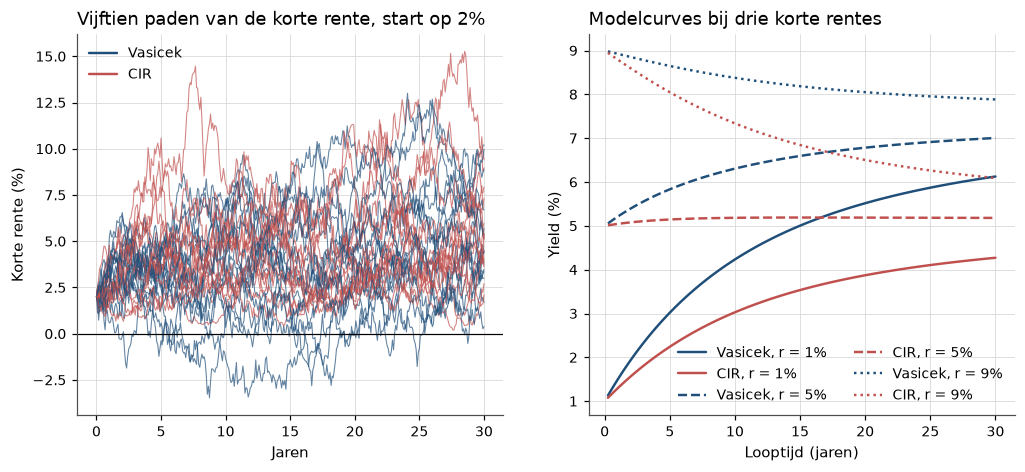

In [6]:
tau_grid = np.linspace(0.25, 30, 120)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
months = np.arange(paths_vas.shape[1]) / 12
for i in range(15):
    axes[0].plot(months, 100 * paths_vas[i], color=hap.plotting.COLORS[0], lw=0.7, alpha=0.7)
    axes[0].plot(months, 100 * paths_cir[i], color=hap.plotting.COLORS[1], lw=0.7, alpha=0.7)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].plot([], [], color=hap.plotting.COLORS[0], label="Vasicek")
axes[0].plot([], [], color=hap.plotting.COLORS[1], label="CIR")
axes[0].set_title("Vijftien paden van de korte rente, start op 2%")
axes[0].set_xlabel("Jaren")
axes[0].set_ylabel("Korte rente (%)")
axes[0].legend()

for r0, ls in [(0.01, "-"), (0.05, "--"), (0.09, ":")]:
    axes[1].plot(tau_grid, 100 * vasicek_yield(r0, tau_grid, KAPPA, THETA, SIGMA_V, LAMBDA),
                 color=hap.plotting.COLORS[0], ls=ls, label=f"Vasicek, r = {r0:.0%}")
    axes[1].plot(tau_grid, 100 * cir_yield(r0, tau_grid, KAPPA, THETA, SIGMA_C, kappa_q_cir),
                 color=hap.plotting.COLORS[1], ls=ls, label=f"CIR, r = {r0:.0%}")
axes[1].set_title("Modelcurves bij drie korte rentes")
axes[1].set_xlabel("Looptijd (jaren)")
axes[1].set_ylabel("Yield (%)")
axes[1].legend(ncol=2)
plt.show()

:::{figure} #cel-termijnstructuur-real-options-paden
:label: fig-termijnstructuur-real-options-paden
:width: 100%

Links: Vasicek-paden zakken onder nul, CIR-paden niet. Rechts: de korte rente bepaalt de
vorm, maar alle curves van één model lopen naar dezelfde lange rente; een eenfactormodel
verschuift de korte kant van de curve, niet de lange.
:::

De stationaire standaarddeviatie van de Vasicek-rente is $\sigma/\sqrt{2\kappa} = 2{,}7\%$,
dus nul ligt 1,8 standaarddeviaties onder het gemiddelde. Van de 5000 Vasicek-paden vanaf
2% zakt 58% in dertig jaar minstens één maand onder nul, 4,7% van alle maanden is
negatief, en de laagste rente is $-6{,}7\%$. Geen enkel CIR-pad komt onder nul.

### Het 2%-motief voor rentemodellen: drift slecht, volatiliteit goed gemeten

De replicatie schat $\kappa$, $\theta$ en $\sigma$ op vijftig jaar maanddata. Hoe goed kan
dat? De Vasicek-transitie is een AR(1) met coëfficiënt $b = e^{-\kappa\Delta}$, dus
kleinste kwadraten is hier exacte maximum likelihood. We schatten op 2000 gesimuleerde
steekproeven van 40 jaar.

In [7]:
def fit_vasicek(r, dt):
    """Exact-discretisation (AR(1) OLS) Vasicek estimates; works on the last axis."""
    x, y = r[..., :-1], r[..., 1:]
    xm, ym = x.mean(-1, keepdims=True), y.mean(-1, keepdims=True)
    b = ((x - xm) * (y - ym)).sum(-1) / ((x - xm) ** 2).sum(-1)
    c = ym[..., 0] - b * xm[..., 0]
    resid_sd = (y - c[..., None] - b[..., None] * x).std(-1)
    kappa = -np.log(b) / dt
    return kappa, c / (1 - b), resid_sd * np.sqrt(2 * kappa / (1 - b**2))


samples = simulate_vasicek(THETA, KAPPA, THETA, SIGMA_V, dt_m, 480, 2000, rng)
k_hat, th_hat, s_hat = fit_vasicek(samples, dt_m)
yinf_hat = th_hat + LAMBDA * s_hat / k_hat - s_hat**2 / (2 * k_hat**2)
yinf_true = THETA + LAMBDA * SIGMA_V / KAPPA - SIGMA_V**2 / (2 * KAPPA**2)

sampling = pd.DataFrame(
    {
        "waar": [KAPPA, THETA, SIGMA_V, yinf_true],
        "p5": np.percentile([k_hat, th_hat, s_hat, yinf_hat], 5, axis=1),
        "mediaan": np.percentile([k_hat, th_hat, s_hat, yinf_hat], 50, axis=1),
        "p95": np.percentile([k_hat, th_hat, s_hat, yinf_hat], 95, axis=1),
    },
    index=["kappa", "theta", "sigma", "lange yield"],
).round(4)
sampling

,waar,p5,mediaan,p95
kappa,0.150,0.0958,0.2410,0.5364
theta,0.050,0.0238,0.0502,0.0754
sigma,0.015,0.0143,0.0150,0.0159
lange yield,0.075,0.0416,0.0674,0.0976


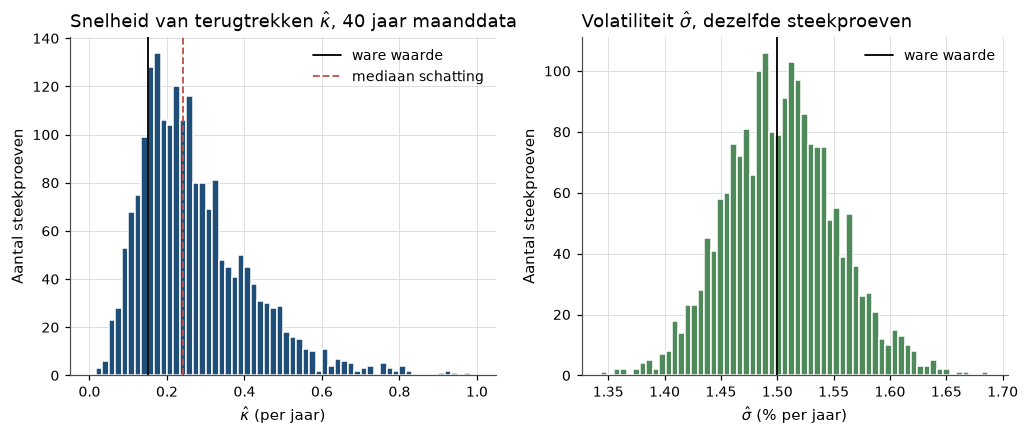

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(k_hat, bins=60, range=(0, 1), color=hap.plotting.COLORS[0], edgecolor="white")
axes[0].axvline(KAPPA, color="black", lw=1.2, label="ware waarde")
axes[0].axvline(np.median(k_hat), color=hap.plotting.COLORS[1], ls="--", lw=1.2, label="mediaan schatting")
axes[0].set_title("Snelheid van terugtrekken $\\hat\\kappa$, 40 jaar maanddata")
axes[0].set_xlabel("$\\hat\\kappa$ (per jaar)")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()
axes[1].hist(100 * s_hat, bins=60, color=hap.plotting.COLORS[2], edgecolor="white")
axes[1].axvline(100 * SIGMA_V, color="black", lw=1.2, label="ware waarde")
axes[1].set_title("Volatiliteit $\\hat\\sigma$, dezelfde steekproeven")
axes[1].set_xlabel("$\\hat\\sigma$ (% per jaar)")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].legend()
plt.show()

:::{figure} #cel-termijnstructuur-real-options-schatting
:label: fig-termijnstructuur-real-options-schatting
:width: 100%

Hetzelfde patroon als bij aandelenrendementen: de volatiliteit van de rente is na
veertig jaar tot op enkele procenten bekend, de snelheid van terugtrekken niet eens tot
op een factor twee.
:::

Dit is het 2%-motief in rentevorm. De drift $\kappa(\theta - r)$ is een eerste moment en
wordt alleen beter gemeten met een langere periode; de volatiliteit wordt met elke
waarneming beter. Het 90%-interval van $\hat\kappa$ loopt van 0,10 tot 0,54 rond een
ware 0,15 (mediaan 0,24), dat van $\hat\sigma$ van 1,43% tot 1,59% rond 1,5%. De lange
Vasicek-yield erft de onzekerheid van de drift: van 4,2% tot 9,8% rond een ware 7,5%. De
opwaartse bias in $\hat\kappa$ is de tijdreeksvariant van de Stambaugh-bias.

### LSM tegen een binomiale boom

We repliceren de eerste rij van tabel 1 van {cite:t}`LongstaffSchwartz2001`: een put met
$S = 36$, $K = 40$, $\sigma = 0{,}20$, $T = 1$ en $r = 6\%$, 50 keer per jaar
uitoefenbaar. Het artikel geeft 4,478 met eindige differenties, 3,844 voor de Europese
put, en 4,472 (standaardfout 0,010) voor LSM met 100.000 paden (50.000 plus 50.000
antithetisch) en een constante plus drie Laguerre-polynomen. Onze benchmark is een
binomiale boom van 5000 stappen waarin elke honderdste stap mag worden uitgeoefend.

In [9]:
def binomial_put(S0, K, r, sigma, T, n_steps, exercise_every=1):
    """CRR binomial American/Bermudan put; exercise allowed every `exercise_every` steps."""
    dt = T / n_steps
    up = np.exp(sigma * np.sqrt(dt))
    q = (np.exp(r * dt) - 1 / up) / (up - 1 / up)
    disc = np.exp(-r * dt)
    S = S0 * up ** np.arange(n_steps, -n_steps - 1, -2)
    V = np.maximum(K - S, 0.0)
    for i in range(n_steps - 1, -1, -1):
        S = S[:-1] / up
        V = disc * (q * V[:-1] + (1 - q) * V[1:])
        if i % exercise_every == 0:
            V = np.maximum(V, K - S)
    return V[0]


def lsm_put(S0, K, r, sigma, T, n_exercise, n_paths, n_laguerre, rng):
    """Longstaff-Schwartz LSM value of a Bermudan put with antithetic paths.

    Regressors: a constant plus the first `n_laguerre` weighted Laguerre polynomials
    of S/K (the scaling keeps the regression well conditioned).
    """
    dt = T / n_exercise
    z = rng.standard_normal((n_paths // 2, n_exercise))
    z = np.vstack([z, -z])
    S = S0 * np.exp(np.cumsum((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z, axis=1))
    cash = np.maximum(K - S[:, -1], 0.0)
    when = np.full(len(S), n_exercise)
    for k in range(n_exercise - 1, 0, -1):
        payoff = K - S[:, k - 1]
        itm = payoff > 0
        x = S[itm, k - 1] / K
        y = cash[itm] * np.exp(-r * dt * (when[itm] - k))
        w = np.exp(-x / 2)
        basis = np.column_stack([np.ones_like(x), w, w * (1 - x), w * (1 - 2 * x + x**2 / 2)])
        design = basis[:, : n_laguerre + 1]
        coef, *_ = np.linalg.lstsq(design, y, rcond=None)
        idx = np.flatnonzero(itm)[payoff[itm] > design @ coef]
        cash[idx], when[idx] = payoff[idx], k
    pv = cash * np.exp(-r * dt * when)
    return pv.mean(), pv.std(ddof=1) / np.sqrt(len(pv))


bermudan_tree = binomial_put(36, 40, 0.06, 0.20, 1.0, 5000, exercise_every=100)
american_tree = binomial_put(36, 40, 0.06, 0.20, 1.0, 5000)
d1 = (np.log(36 / 40) + (0.06 + 0.02) * 1.0) / 0.20
european_bs = 40 * np.exp(-0.06) * stats.norm.cdf(-(d1 - 0.20)) - 36 * stats.norm.cdf(-d1)

rows = {}
for n_lag in range(4):
    value, se = lsm_put(36, 40, 0.06, 0.20, 1.0, 50, 100_000, n_lag, rng)
    rows[f"constante + {n_lag} Laguerre"] = [value, se, value - bermudan_tree]
lsm_table = pd.DataFrame(rows, index=["LSM-waarde", "standaardfout", "verschil met boom"]).T.round(4)
print(f"boom (50 uitoefenmomenten/jaar): {bermudan_tree:.4f}   continu Amerikaans: {american_tree:.4f}"
      f"   Europees (BS): {european_bs:.4f}")
lsm_table

boom (50 uitoefenmomenten/jaar): 4.4779   continu Amerikaans: 4.4867   Europees (BS): 3.8443


,LSM-waarde,standaardfout,verschil met boom
constante + 0 Laguerre,4.3299,0.0062,-0.1480
constante + 1 Laguerre,4.4485,0.0098,-0.0294
constante + 2 Laguerre,4.4651,0.0091,-0.0128
constante + 3 Laguerre,4.4829,0.0094,0.0050


De boom geeft 4,478 en de Europese waarde 3,844, als in het artikel. LSM met drie
polynomen geeft 4,483 (standaardfout 0,009), binnen één standaardfout van de boom. Met
alleen een constante is de doorgaanswaarde één getal voor alle paden in het geld en de
waarde 4,330, bijna vijftien cent te laag, zoals
[](#thm-termijnstructuur-real-options-ondergrens) voorspelt; met één en twee polynomen
4,449 en 4,465. De continu uitoefenbare put is 4,487 waard. Hieronder twintig
herhalingen per aantal paden.

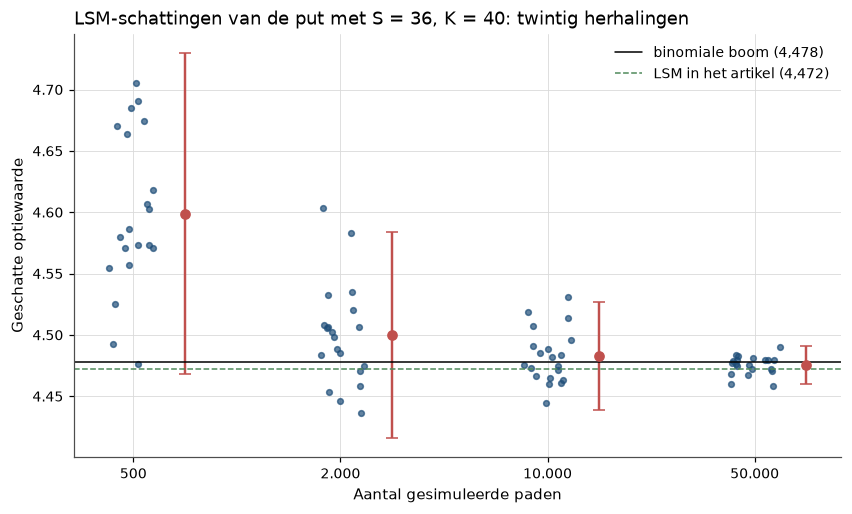

,gemiddelde,std. over herhalingen
paden,,
500,4.5989,0.0655
2000,4.4999,0.0419
10000,4.4826,0.0221
50000,4.4754,0.0078


In [10]:
path_counts = [500, 2_000, 10_000, 50_000]
reps = 20
estimates = {n: [lsm_put(36, 40, 0.06, 0.20, 1.0, 50, n, 3, rng)[0] for _ in range(reps)]
             for n in path_counts}

fig, ax = plt.subplots()
for i, n in enumerate(path_counts):
    ax.scatter(np.full(reps, i) + rng.uniform(-0.12, 0.12, reps), estimates[n],
               color=hap.plotting.COLORS[0], s=14, alpha=0.7)
    ax.errorbar(i + 0.25, np.mean(estimates[n]), yerr=2 * np.std(estimates[n], ddof=1),
                color=hap.plotting.COLORS[1], capsize=4, marker="o")
ax.axhline(bermudan_tree, color="black", lw=1, label="binomiale boom (4,478)")
ax.axhline(4.472, color=hap.plotting.COLORS[2], ls="--", lw=1, label="LSM in het artikel (4,472)")
ax.set_xticks(range(len(path_counts)), [f"{n:,}".replace(",", ".") for n in path_counts])
ax.set_title("LSM-schattingen van de put met S = 36, K = 40: twintig herhalingen")
ax.set_xlabel("Aantal gesimuleerde paden")
ax.set_ylabel("Geschatte optiewaarde")
ax.legend()
plt.show()

lsm_spread = pd.DataFrame(
    {"gemiddelde": [np.mean(estimates[n]) for n in path_counts],
     "std. over herhalingen": [np.std(estimates[n], ddof=1) for n in path_counts]},
    index=pd.Index(path_counts, name="paden"),
).round(4)
lsm_spread

:::{figure} #cel-termijnstructuur-real-options-lsm
:label: fig-termijnstructuur-real-options-lsm
:width: 90%

De spreiding krimpt ongeveer met $1/\sqrt{N}$, van 0,066 bij 500 paden tot 0,008 bij
50.000. Bij 500 paden ligt het gemiddelde met 4,60 *boven* de boom: de regressie kent de
toekomst van de paden waarop gewaardeerd wordt, en die vooruitziende blik weegt zwaarder
dan de suboptimale grens. Bij 50.000 paden (4,475) wint de ondergrens.
:::

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Vasicek, *An Equilibrium Characterization of the Term Structure*, Journal of
Financial Economics 1977 {cite}`Vasicek1977`; Cox, Ingersoll & Ross, *A Theory of the
Term Structure of Interest Rates*, Econometrica 1985 {cite}`CoxIngersollRoss1985`;
Litterman & Scheinkman, *Common Factors Affecting Bond Returns*, Journal of Fixed Income
1991 {cite}`LittermanScheinkman1991`.

**Wat.** (i) Vasicek- en CIR-parameters op de korte rente, en de modelcurve naast de
waargenomen curve op vijf datums. (ii) Tabel 2 van Litterman en Scheinkman: drie
factoren verklaren gemiddeld 98,4% van de variantie van rendementen op
nulcouponobligaties (89,5% level, 8,5% steepness, 2,0% curvature), voor elke obligatie
minstens 96%.

**Data hier.** De maandelijkse driemaands-T-billrente `TB3MS` van FRED, 1971-08 t/m
2026-08, via `hap.data.fred("TB3MS")`, en de nulcouponcurve van Gürkaynak, Sack en Wright
(looptijden 1–30 jaar, maandeinde) via `hap.data.gsw()`.

**Verschil met het origineel.** Vasicek en CIR schatten geen parameters; wij gebruiken
maximum likelihood. `TB3MS` is een maandgemiddelde op discontobasis, geen instantane
rente. Litterman en Scheinkman gebruikten wekelijkse excess rendementen, januari 1984
t/m juni 1988; wij maandelijkse veranderingen in GSW-yields over veertig tot vijftig
jaar. De gladde Svensson-fit verhoogt het aandeel van de eerste componenten mechanisch.

**Verwachte afwijking.** Drie componenten verklaren meer dan 95%; de eerste heeft ladingen
van hetzelfde teken op alle looptijden, de tweede verandert één keer van teken. De
correlatie tussen veranderingen in de 1- en de 10-jaarsyield ligt duidelijk onder de 1
van een eenfactormodel. Vasicek met constante marktprijs van risico zit in 1981 en in
2021 met de 10-jaarsyield meer dan een procentpunt naast de GSW-curve, in tegengestelde
richting. Wijkt het teken van die fouten af, dan zit er een fout in de code.
```

### Vasicek en CIR op de driemaandsrente

In [11]:
short = (hap_data.fred("TB3MS")["TB3MS"] / 100).loc["1971-08":]
short.index = short.index + pd.offsets.MonthEnd(0)
dt_m = 1 / 12

# Vasicek: exact AR(1) with delta-method standard errors
ols = sm.OLS(short.values[1:], sm.add_constant(short.values[:-1])).fit()
c_hat, b_hat = ols.params
cov_cb = ols.cov_params()
kappa_v = -np.log(b_hat) / dt_m
theta_v = c_hat / (1 - b_hat)
sigma_v = np.std(ols.resid, ddof=2) * np.sqrt(2 * kappa_v / (1 - b_hat**2))
grad_kappa = np.array([0.0, -1 / (b_hat * dt_m)])
grad_theta = np.array([1 / (1 - b_hat), c_hat / (1 - b_hat) ** 2])
se_kappa_v = np.sqrt(grad_kappa @ cov_cb @ grad_kappa)
se_theta_v = np.sqrt(grad_theta @ cov_cb @ grad_theta)


# CIR: maximum likelihood with the noncentral chi-square transition density
def cir_negloglik(log_params, x, dt):
    kappa, theta, sigma = np.exp(log_params)
    c = 2 * kappa / (sigma**2 * (1 - np.exp(-kappa * dt)))
    df = 4 * kappa * theta / sigma**2
    nonc = 2 * c * x[:-1] * np.exp(-kappa * dt)
    return -np.sum(np.log(2 * c) + stats.ncx2.logpdf(2 * c * x[1:], df, nonc))


fit_cir = optimize.minimize(cir_negloglik, np.log([0.2, 0.04, 0.08]), args=(short.values, dt_m),
                            method="Nelder-Mead", options={"maxiter": 4000, "xatol": 1e-8, "fatol": 1e-8})
kappa_c, theta_c, sigma_c = np.exp(fit_cir.x)

estimates_table = pd.DataFrame(
    {
        "Vasicek": [kappa_v, theta_v, sigma_v, se_kappa_v, se_theta_v, np.nan],
        "CIR": [kappa_c, theta_c, sigma_c, np.nan, np.nan, 2 * kappa_c * theta_c / sigma_c**2],
    },
    index=["kappa", "theta", "sigma", "SE kappa", "SE theta", "Feller 2*kappa*theta/sigma^2"],
).round(4)
estimates_table

,Vasicek,CIR
kappa,0.1003,0.0482
theta,0.0418,0.0394
sigma,0.0151,0.0608
SE kappa,0.0608,NaN
SE theta,0.0203,NaN
Feller 2*kappa*theta/sigma^2,NaN,1.0267


Vasicek schat $\hat\kappa = 0{,}10$ per jaar (halfwaardetijd $\log 2/\hat\kappa \approx
7$ jaar) met standaardfout 0,06, een $t$-waarde van 1,6; $\hat\theta = 4{,}2\%$ heeft
een standaardfout van 2,0 procentpunt, terwijl $\hat\sigma = 1{,}5\%$ scherp bepaald is,
zoals de simulatie voorspelde. CIR vindt $\hat\kappa = 0{,}05$ en een Feller-verhouding
van 1,03, net boven één: de rente lag in 2009–2015 en 2020–2021 jarenlang bij nul.

### De modelcurve naast de waargenomen curve

De tijdreeks van de korte rente legt $\kappa$, $\theta$ en $\sigma$ vast, maar niet de
marktprijs van risico: die zit alleen in de curve. We kiezen per model één constante
$\lambda$ (voor CIR één risiconeutrale $\kappa^{*}$) die de kwadratische afstand tot de
GSW-yields van 1 tot 10 jaar over alle maanden minimaliseert.

In [12]:
gsw_month = hap_data.gsw().resample("ME").last()
maturities = np.arange(1, 31)
yield_cols = [f"SVENY{m:02d}" for m in maturities]
curves = gsw_month[yield_cols].loc["1971-08":]
common = curves.index.intersection(short.index)
fit_block = curves.loc[common, yield_cols[:10]]
mask = fit_block.notna().to_numpy()
r_now = short.loc[common].to_numpy()[:, None]
tau10 = maturities[None, :10].astype(float)


def mse_vasicek(lam):
    model = vasicek_yield(r_now, tau10, kappa_v, theta_v, sigma_v, lam)
    return np.mean((model - fit_block.to_numpy())[mask] ** 2)


def mse_cir(kappa_q):
    model = cir_yield(r_now, tau10, kappa_c, theta_c, sigma_c, kappa_q)
    return np.mean((model - fit_block.to_numpy())[mask] ** 2)


lam_v = optimize.minimize_scalar(mse_vasicek, bounds=(-5, 5), method="bounded")
kq_c = optimize.minimize_scalar(mse_cir, bounds=(-0.5, 1.0), method="bounded")

dates = ["1981-09-30", "2000-06-30", "2008-12-31", "2021-06-30", str(common[-1].date())]
rows = []
for date in dates:
    r_d = short.loc[date]
    for m in (1, 5, 10):
        rows.append({
            "datum": date[:7], "looptijd": m,
            "GSW": curves.loc[date, f"SVENY{m:02d}"],
            "Vasicek": vasicek_yield(r_d, m, kappa_v, theta_v, sigma_v, lam_v.x),
            "CIR": cir_yield(r_d, m, kappa_c, theta_c, sigma_c, kq_c.x),
        })
fit_table = pd.DataFrame(rows).set_index(["datum", "looptijd"])
fit_table["fout Vasicek"] = fit_table["Vasicek"] - fit_table["GSW"]
fit_table["fout CIR"] = fit_table["CIR"] - fit_table["GSW"]
print(f"Vasicek: lambda = {lam_v.x:.3f}, RMSE = {1e4 * np.sqrt(lam_v.fun):.0f} bp, "
      f"lange yield = {vasicek_yield(0.0, 1e4, kappa_v, theta_v, sigma_v, lam_v.x):.2%}")
print(f"CIR: kappa* = {kq_c.x:.3f}, RMSE = {1e4 * np.sqrt(kq_c.fun):.0f} bp")
(100 * fit_table).round(2)

Vasicek: lambda = 0.351, RMSE = 115 bp, lange yield = 8.31%
CIR: kappa* = -0.021, RMSE = 124 bp


GSW  Vasicek    CIR  fout Vasicek  fout CIR
datum   looptijd                                               
1981-09 1         15.69    14.44  14.94         -1.25     -0.75
        5         15.18    13.51  15.76         -1.67      0.58
        10        14.89    12.57  16.34         -2.32      1.45
2000-06 1          6.41     5.87   5.84         -0.54     -0.56
        5          6.15     6.43   6.40          0.28      0.25
        10         6.17     6.88   6.93          0.71      0.76
2008-12 1          0.38     0.48   0.13          0.10     -0.26
        5          1.56     1.97   0.52          0.42     -1.04
        10         2.88     3.31   1.02          0.43     -1.86
2021-06 1          0.10     0.49   0.14          0.39      0.03
        5          0.88     1.98   0.53          1.10     -0.35
        10         1.53     3.32   1.03          1.79     -0.50
2026-08 1          4.20     3.99   3.85         -0.20     -0.34
        5          4.48     4.88   4.35          0.40     -0.12
        10         4.80     5.64   4.87          0.84      0.07

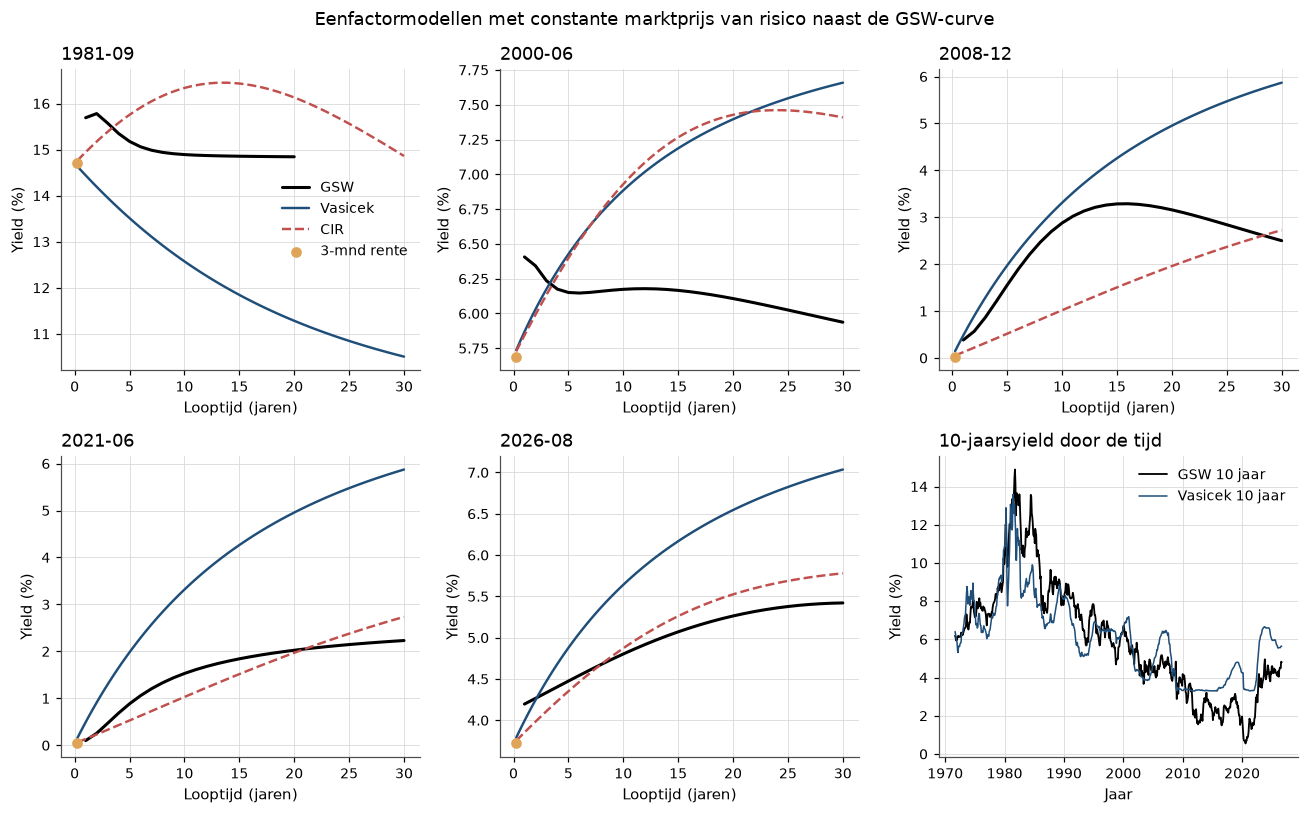

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7.5))
tau_fine = np.linspace(0.25, 30, 120)
for ax, date in zip(axes.flat, dates):
    obs = curves.loc[date].dropna()
    r_d = short.loc[date]
    ax.plot(maturities[: len(obs)], 100 * obs.to_numpy(), color="black", lw=2, label="GSW")
    ax.plot(tau_fine, 100 * vasicek_yield(r_d, tau_fine, kappa_v, theta_v, sigma_v, lam_v.x),
            color=hap.plotting.COLORS[0], label="Vasicek")
    ax.plot(tau_fine, 100 * cir_yield(r_d, tau_fine, kappa_c, theta_c, sigma_c, kq_c.x),
            color=hap.plotting.COLORS[1], ls="--", label="CIR")
    ax.scatter([0.25], [100 * r_d], color=hap.plotting.COLORS[3], zorder=3, label="3-mnd rente")
    ax.set_title(date[:7])
    ax.set_xlabel("Looptijd (jaren)")
    ax.set_ylabel("Yield (%)")
axes.flat[0].legend()

ax = axes.flat[5]
ten = curves.loc[common, "SVENY10"]
ax.plot(ten.index, 100 * ten, color="black", lw=1.2, label="GSW 10 jaar")
ax.plot(common, 100 * vasicek_yield(short.loc[common].to_numpy(), 10.0, kappa_v, theta_v, sigma_v, lam_v.x),
        color=hap.plotting.COLORS[0], lw=1, label="Vasicek 10 jaar")
ax.set_title("10-jaarsyield door de tijd")
ax.set_xlabel("Jaar")
ax.set_ylabel("Yield (%)")
ax.legend()
fig.suptitle("Eenfactormodellen met constante marktprijs van risico naast de GSW-curve")
plt.tight_layout()
plt.show()

:::{figure} #cel-termijnstructuur-real-options-curves
:label: fig-termijnstructuur-real-options-curves
:width: 100%

In 1981 zet Vasicek de 10-jaarsyield 2,3 procentpunt te laag, in 2021 1,8 procentpunt te
hoog; CIR zit in 2008 1,9 procentpunt te laag. Rechtsonder: de modelimplied
10-jaarsyield volgt de korte rente, de waargenomen lange rente beweegt trager en op
eigen kracht.
:::

De gekalibreerde $\lambda = 0{,}35$ geeft een positieve term premium en een oneindig
lange yield van 8,3%, één getal voor een periode waarin de 10-jaarsyield van bijna 15%
naar onder 2% ging. Gemiddeld zit Vasicek 115 basispunten naast de 1- tot
10-jaarsyields, CIR 124. Met een lange rente die aan $\theta$ vastzit, kan Vasicek een
hoge lange rente niet samen met een hoge korte rente verklaren (1981), en een lage lange
rente niet samen met een korte rente van nul (2021). CIR loopt in de omgekeerde fout:
met $\kappa^{*} = -0{,}02$ stijgt de curve bij een hoge rente te steil (1,5 procentpunt
te hoog in 1981) en blijft ze bij een rente van nul, waar de vierkantswortel de
volatiliteit uitschakelt, te vlak (1,9 procentpunt te laag in 2008). Dat is
[](#cor-termijnstructuur-real-options-correlatie) in de vorm van een curve.

### Drie factoren: level, slope en curvature

In [14]:
pca_cols = yield_cols[:10]
changes = curves[pca_cols].dropna().diff().dropna()
eigval, eigvec = np.linalg.eigh(np.cov(changes.to_numpy().T))
order = np.argsort(eigval)[::-1]
eigval, eigvec = eigval[order], eigvec[:, order]
eigvec = eigvec * np.sign(eigvec[-1])  # orient: positive loading at 10 years

long_changes = curves[yield_cols].dropna().diff().dropna()
eigval_30 = np.sort(np.linalg.eigvalsh(np.cov(long_changes.to_numpy().T)))[::-1]

pca_table = pd.DataFrame(
    {
        "Litterman-Scheinkman 1991": [89.5, 8.5, 2.0, 98.4],
        f"GSW 1-10 jaar, {changes.index[0]:%Y-%m}–{changes.index[-1]:%Y-%m}":
            np.append(100 * eigval[:3] / eigval.sum(), 100 * eigval[:3].sum() / eigval.sum()),
        f"GSW 1-30 jaar, {long_changes.index[0]:%Y-%m}–{long_changes.index[-1]:%Y-%m}":
            np.append(100 * eigval_30[:3] / eigval_30.sum(), 100 * eigval_30[:3].sum() / eigval_30.sum()),
    },
    index=["factor 1 (level)", "factor 2 (steepness)", "factor 3 (curvature)", "totaal drie factoren"],
).round(1)
corr_1_10 = changes["SVENY01"].corr(changes["SVENY10"])
print(f"correlatie van maandelijkse veranderingen 1 en 10 jaar: {corr_1_10:.2f} (eenfactormodel: 1)")
pca_table

correlatie van maandelijkse veranderingen 1 en 10 jaar: 0.69 (eenfactormodel: 1)


,Litterman-Scheinkman 1991,"GSW 1-10 jaar, 1971-09–2026-08","GSW 1-30 jaar, 1985-12–2026-08"
factor 1 (level),89.5,91.7,89.0
factor 2 (steepness),8.5,7.3,7.7
factor 3 (curvature),2.0,0.9,2.3
totaal drie factoren,98.4,99.9,98.9


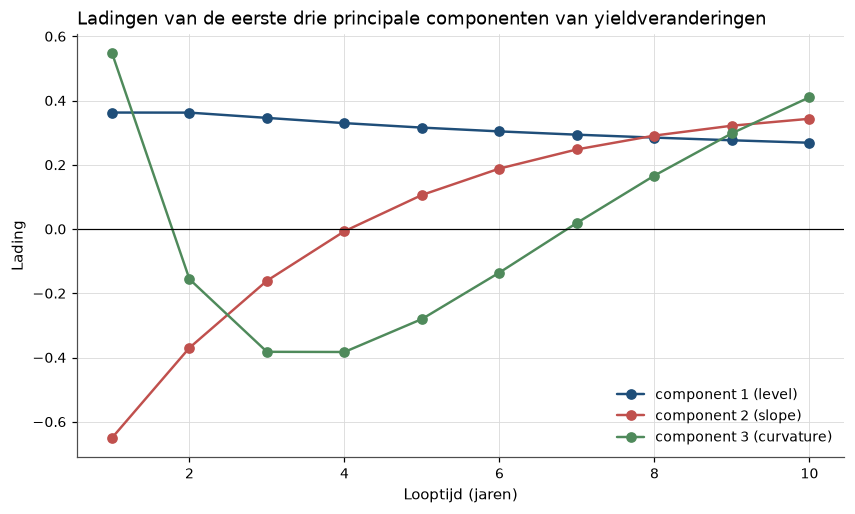

In [15]:
fig, ax = plt.subplots()
labels = ["level", "slope", "curvature"]
for j in range(3):
    ax.plot(np.arange(1, 11), eigvec[:, j], marker="o", label=f"component {j + 1} ({labels[j]})")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Ladingen van de eerste drie principale componenten van yieldveranderingen")
ax.set_xlabel("Looptijd (jaren)")
ax.set_ylabel("Lading")
ax.legend()
plt.show()

:::{figure} #cel-termijnstructuur-real-options-pca
:label: fig-termijnstructuur-real-options-pca
:width: 90%

De eerste component heeft positieve ladingen op alle looptijden, licht aflopend: een
bijna parallelle verschuiving (level). De tweede verandert tussen vier en vijf jaar van
teken: kort en lang bewegen tegengesteld (slope). De derde is positief aan beide
uiteinden en negatief in het midden (curvature): dezelfde vormen als in figuur 2 van
Litterman en Scheinkman.
:::

Litterman en Scheinkman vonden gemiddeld 89,5%, 8,5% en 2,0% (hun tabel 2). Op GSW-data
tot 30 jaar vinden we 89,0%, 7,7% en 2,3%, samen 98,9%; tot 10 jaar vanaf 1971 91,7%,
7,3% en 0,9%. De verdeling is bijna dezelfde; de iets hogere totalen komen deels door de
gladde Svensson-curve. De correlatie tussen maandelijkse veranderingen in de 1- en de
10-jaarsyield is 0,69.

Dat is het falen van eenfactormodellen in twee getallen:
[](#cor-termijnstructuur-real-options-correlatie) voorspelt één component en een
correlatie van één. Dat de eerste component negen tiende verklaart, laat zien waarom
Vasicek als benadering bruikbaar was; maar Litterman en Scheinkman openden hun artikel
met een duration-neutrale portefeuille die tussen 5 februari en 5 maart 1986 \$650.000
zou hebben verloren, vooral door de curvaturefactor.

## Wat er brak, en wat daarna kwam

**Wat de modellen verklaren.** Veel, en blijvend. Eén arbitrageargument maakt van een
rentedynamiek en één marktprijs van risico een consistente prijs voor elke obligatie en
obligatieoptie, en met Duffie en Kan werd dat een klasse waarin elk later model een
keuze van factoren is. Dezelfde PDE maakte van investeringsbeslissingen opties, en LSM
maakte Amerikaanse opties op veel factoren rekenbaar (4,483 tegen een boom van 4,478).
De eerste principale component verklaart 89% van de variantie van yieldveranderingen:
één factor vangt het grootste deel van het renterisico.

**Waar het breekt.** Een eenfactormodel met constante marktprijs van risico kan de korte en
de lange kant niet tegelijk passen. Geschat op vijftig jaar driemaandsrente zit Vasicek met
de 10-jaarsyield in 1981 2,3 procentpunt te laag en in 2021 1,8 procentpunt te hoog; de
correlatie van veranderingen in de 1- en 10-jaarsyield is 0,69 in plaats van 1; en er zijn
drie factoren. Daaronder ligt het 2%-motief in rentevorm: de drift waar de lange yields van
afhangen, is na vijftig jaar nauwelijks gemeten ($t = 1{,}6$ voor $\hat\kappa$).

**Risico of vergissing?** De Chicago-lezing: de marktprijs van risico is niet constant.
Na een decennium van inflatie eisten beleggers in 1981 een hoge vergoeding voor
renterisico, in 2021 een lage; een model met tijdvariërende $\lambda$ past beide datums,
en de fout is een gemeten risicopremie. De Yale-lezing: lange rentes bewegen meer dan
verwachtingen over korte rentes rechtvaardigen, omdat beleggers recente inflatie
extrapoleren of omdat pensioenfondsen en centrale banken lange obligaties kopen ongeacht
de prijs, en arbitrageurs met beperkt kapitaal dat niet wegwerken. Beide lezingen
voorspellen dat het extra rendement op lange obligaties uit de vorm van de curve te
voorspellen is; of dat een vergoeding is voor risico dat in slechte tijden toeslaat,
vraagt de stochastic discount factor in episodes als 1979–1981, 2008 en 2022, en daarvan
zijn er te weinig. Ook een hoge investeringsdrempel is ofwel de prijs van
onomkeerbaarheid, ofwel een bestuur dat risico overschat. Wie in 1981 een lange
obligatie tegen 15% kocht, droeg in Santa-Clara's woorden "risk that was priced", of
dacht iets te weten wat de prijs niet wist. De data van deze lecture kiezen niet.

**Wat er daarna kwam.** De term premium wordt in Deel V een eigen onderzoeksobject, maar
eerst keert het vak terug naar de cross-sectie van aandelen, waar Fama en French de
anomalieën van Basu, Banz en Rosenberg in één regressie samenbrachten: zie
[](#04-18-fama-french).

## Oefeningen

:::{exercise}
:label: ex-termijnstructuur-real-options-1

**Vasicek zonder Riccati.** Neem onder $\mathbb{Q}$
$\mathrm{d}r = \kappa(\theta^{*} - r)\,\mathrm{d}t + \sigma\,\mathrm{d}W^{\mathbb{Q}}$.

1. Laat zien dat $X = \int_t^T r_s\,\mathrm{d}s$ normaal verdeeld is met gemiddelde
   $\theta^{*}\tau + (r_t - \theta^{*})B(\tau)$ en variantie
   $\sigma^2\big[(\tau - B)/\kappa^2 - B^2/(2\kappa)\big]$, en leid daaruit
   [](#eq-termijnstructuur-real-options-vasicek) af.
2. Controleer het met Monte Carlo: 20.000 paden met dagelijkse stappen, $\kappa = 0{,}15$,
   $\theta = 5\%$, $\sigma = 1{,}5\%$, $\lambda = 0{,}3$, $r_0 = 2\%$ en $\tau = 5$.
3. Hoeveel verlaagt het convexiteitseffect de 30-jaarsyield en de oneindig lange yield?
:::

:::{solution} ex-termijnstructuur-real-options-1
:class: dropdown

**(1)** De Ornstein-Uhlenbeck-oplossing is
$r_s = \theta^{*} + (r_t - \theta^{*})e^{-\kappa(s-t)} + \sigma\int_t^s e^{-\kappa(s-u)}\,\mathrm{d}W_u$.
Integreren en de integratievolgorde verwisselen geeft
$X = \theta^{*}\tau + (r_t - \theta^{*})B(\tau) + \sigma\int_t^T B(T-u)\,\mathrm{d}W_u$,
normaal met variantie $\sigma^2\int_0^\tau B^2$ uit het bewijs van
[](#thm-termijnstructuur-real-options-vasicek). Met
$\E[e^{-X}] = \exp(-\E[X] + \tfrac12\Var(X))$:

$$
\log P = -\theta^{*}\tau - (r_t - \theta^{*})B + \frac{\sigma^2}{2\kappa^2}(\tau - B) - \frac{\sigma^2B^2}{4\kappa}
       = \Big(\theta^{*} - \frac{\sigma^2}{2\kappa^2}\Big)(B - \tau) - \frac{\sigma^2B^2}{4\kappa} - B\,r_t .
$$

**(2) en (3)**

In [16]:
kappa, theta, sigma, lam, r0, tau = 0.15, 0.05, 0.015, 0.3, 0.02, 5.0
theta_q = theta + lam * sigma / kappa
n_paths, n_steps = 20_000, 252 * 5
step = tau / n_steps
a = np.exp(-kappa * step)
sd = sigma * np.sqrt((1 - a**2) / (2 * kappa))
r = np.full(n_paths, r0)
integral = np.zeros(n_paths)
for _ in range(n_steps):
    r_next = theta_q + a * (r - theta_q) + sd * rng.standard_normal(n_paths)
    integral += 0.5 * (r + r_next) * step
    r = r_next
discount = np.exp(-integral)
closed = np.exp(-tau * vasicek_yield(r0, tau, kappa, theta, sigma, lam))
print(f"Monte Carlo: {discount.mean():.5f} (s.e. {discount.std(ddof=1) / np.sqrt(n_paths):.5f}), "
      f"gesloten vorm: {closed:.5f}")

B30 = (1 - np.exp(-kappa * 30)) / kappa
convexity_30 = sigma**2 / (2 * kappa**2) * (1 - B30 / 30) - sigma**2 * B30**2 / (4 * kappa * 30)
print(f"convexiteit 30 jaar: {convexity_30:.2%};  oneindig lang: {sigma**2 / (2 * kappa**2):.2%}")

Monte Carlo: 0.82962 (s.e. 0.00044), gesloten vorm: 0.83013
convexiteit 30 jaar: 0.34%;  oneindig lang: 0.50%


De Monte-Carloprijs ligt binnen een paar standaardfouten van de gesloten vorm. Het
convexiteitseffect verlaagt de 30-jaarsyield met ongeveer 0,34 en de oneindig lange
yield met 0,50 procentpunt, klein naast de term premium van 3% maar groeiend met
$\sigma^2/\kappa^2$: Jensens ongelijkheid uit het toy-voorbeeld, voor een normale
integraal.
:::

:::{exercise}
:label: ex-termijnstructuur-real-options-2

**De drempel van McDonald en Siegel.** Neem $r = \delta = 4\%$.

1. Bereken $\beta$ en $V^{*}/I$ uit [](#eq-termijnstructuur-real-options-drempel) voor
   $\sigma \in \{10\%, 20\%, 30\%\}$.
2. Controleer de drempel met een binomiale boom: waardeer de optie om te investeren als
   Amerikaanse call op $V$ met $I = 1$ en een looptijd van 50 jaar, en zoek met bisectie de
   laagste $V$ waarbij direct investeren optimaal is.
3. Wat gebeurt er met $V^{*}/I$ als $\delta \to 0$? Verbind dit met Mertons resultaat over
   Amerikaanse calls uit [](#02-09-black-scholes).
:::

:::{solution} ex-termijnstructuur-real-options-2
:class: dropdown

In [17]:
def beta_mcdonald_siegel(r, delta, sigma):
    """Positive root of the fundamental quadratic for a perpetual investment option."""
    a = (r - delta) / sigma**2 - 0.5
    return -a + np.sqrt(a**2 + 2 * r / sigma**2)


def american_call(V0, K, r, delta, sigma, T, n_steps):
    """CRR American call on an asset with payout rate delta."""
    dt = T / n_steps
    up = np.exp(sigma * np.sqrt(dt))
    q = (np.exp((r - delta) * dt) - 1 / up) / (up - 1 / up)
    disc = np.exp(-r * dt)
    V = V0 * up ** np.arange(n_steps, -n_steps - 1, -2)
    F = np.maximum(V - K, 0.0)
    for _ in range(n_steps):
        V = V[:-1] / up
        F = np.maximum(disc * (q * F[:-1] + (1 - q) * F[1:]), V - K)
    return F[0]


def tree_threshold(r, delta, sigma, T=50.0, n_steps=2000):
    """Smallest V at which the tree says: invest now (bisection)."""
    lo, hi = 1.0, 10.0
    for _ in range(25):
        mid = 0.5 * (lo + hi)
        if american_call(mid, 1.0, r, delta, sigma, T, n_steps) <= mid - 1.0 + 1e-12:
            hi = mid
        else:
            lo = mid
    return hi


rows_ms = {}
for s in (0.10, 0.20, 0.30):
    b = beta_mcdonald_siegel(0.04, 0.04, s)
    rows_ms[s] = {"beta": b, "V*/I formule": b / (b - 1), "V*/I boom": tree_threshold(0.04, 0.04, s)}
thresholds = pd.DataFrame(rows_ms).T.rename_axis("sigma").round(3)
b_small = beta_mcdonald_siegel(0.04, 0.001, 0.20)
print(f"V*/I bij delta = 0,1% en sigma = 20%: {b_small / (b_small - 1):.1f}")
thresholds

V*/I bij delta = 0,1% en sigma = 20%: 60.3


,beta,V*/I formule,V*/I boom
sigma,,,
0.1,3.372,1.422,1.408
0.2,2.000,2.000,1.963
0.3,1.567,2.763,2.690


Bij $\sigma = 20\%$ is $\beta = 2$ en de drempel twee keer de kosten; bij 10% is ze
1,42, bij 30% 2,76. De boom geeft iets lagere drempels (1,41, 1,96 en 2,69), omdat een
optie van vijftig jaar minder waard is dan een eeuwigdurende. Als $\delta \to 0$ gaat de
drempel naar oneindig (bij $\delta = 0{,}1\%$ al ongeveer 60): zonder gemiste opbrengst
wacht je altijd, zoals een Amerikaanse call op een aandeel zonder dividend nooit vroeg
wordt uitgeoefend. "Twee keer de kosten" is een optiewaarde, geen vuistregel.
:::

:::{exercise}
:label: ex-termijnstructuur-real-options-3

**Twee deelsteekproeven.** Herhaal de replicatie op 1971-08 t/m 1999-12 en op 2000-01 t/m
2026-08.

1. Schat Vasicek op de driemaandsrente in beide perioden, met standaardfouten voor
   $\hat\kappa$ en $\hat\theta$.
2. Bereken in beide perioden de correlatie tussen maandelijkse veranderingen in de 1- en de
   10-jaarsyield en het aandeel van de eerste principale component (1–10 jaar).
3. Welke parameter verschilt het meest? Past één eenfactormodel op beide perioden?
:::

:::{solution} ex-termijnstructuur-real-options-3
:class: dropdown

In [18]:
def vasicek_with_se(x, dt=1 / 12):
    """Vasicek AR(1) estimates with delta-method standard errors."""
    fit = sm.OLS(x[1:], sm.add_constant(x[:-1])).fit()
    c, b = fit.params
    cov = fit.cov_params()
    kappa = -np.log(b) / dt
    g_kappa = np.array([0.0, -1 / (b * dt)])
    g_theta = np.array([1 / (1 - b), c / (1 - b) ** 2])
    return {
        "kappa": kappa, "SE kappa": np.sqrt(g_kappa @ cov @ g_kappa),
        "theta": c / (1 - b), "SE theta": np.sqrt(g_theta @ cov @ g_theta),
        "sigma": np.std(fit.resid, ddof=2) * np.sqrt(2 * kappa / (1 - b**2)),
    }


periods = {"1971-1999": ("1971-08", "1999-12"), "2000-2026": ("2000-01", "2026-08")}
rows_sub = {}
for label, (start, end) in periods.items():
    est = vasicek_with_se(short.loc[start:end].to_numpy())
    block = changes.loc[start:end]
    ev = np.sort(np.linalg.eigvalsh(np.cov(block.to_numpy().T)))[::-1]
    est["corr 1j-10j"] = block["SVENY01"].corr(block["SVENY10"])
    est["aandeel PC1"] = ev[0] / ev.sum()
    rows_sub[label] = est
subsamples = pd.DataFrame(rows_sub)
for name in ("kappa", "theta"):
    diff = subsamples.loc[name].diff().iloc[-1]
    se = np.sqrt((subsamples.loc[f"SE {name}"] ** 2).sum())
    print(f"verschil in {name}: {diff:.4f}, in standaardfouten: {diff / se:.2f}")
subsamples.round(4)

verschil in kappa: -0.1799, in standaardfouten: -1.15
verschil in theta: -0.0543, in standaardfouten: -2.86


,1971-1999,2000-2026
kappa,0.2794,0.0995
SE kappa,0.1420,0.0660
theta,0.0675,0.0132
SE theta,0.0135,0.0133
sigma,0.0201,0.0065
corr 1j-10j,0.7610,0.5562
aandeel PC1,0.9346,0.9093


Vóór 2000 is $\hat\kappa = 0{,}28$ (standaardfout 0,14) en $\hat\theta = 6{,}8\%$,
daarna $0{,}10$ (0,07) en 1,3%: verschillen van 1,1 en $-2{,}9$ standaardfouten. De
volatiliteit daalt van 2,0% naar 0,65%, de correlatie tussen 1- en 10-jaarsveranderingen
van 0,76 naar 0,56 en het aandeel van de eerste component van 93,5% naar 90,9%. Eén
eenfactormodel met vaste parameters past niet op beide perioden, en de breuk is het
scherpst in de tweede momenten, die het 2%-motief goed meetbaar noemt.
:::